# PDBbind density normalisation: distribution comparison

Five density-normalisation variants of the PDBbind pocket crops, all on the same 4,827 complexes — all generated on disk by `dataset/01b_pdbbind_preprocess.py poolnorm`:

| Version | Pipeline | Output range |
|---|---|---|
| **v1** | per-map global z-score (`_load_grid`) → trilinear crop at ligand COM → per-crop ±3σ clip + re-z-score (`normalize_crop`) | ≈ mean 0, std 1, hard-clipped at ±3 |
| **v2** | raw CCP4 → trilinear crop → pocket-pool z-score `(x − μ_pool) / σ_pool` | mean 0, std 1 across the pool |
| **v3** | raw CCP4 → trilinear crop → pocket-pool symmetric max-abs `x / max_abs_pool` | strict `[−1, +1]` |
| **v4** | raw → clip to fixed window `[−0.578, +1.647]` (P0.1/P99.9) → pocket-pool z-score | ≈ mean 0, std 1, bounded ≈ `[−1.8, +5.2]` |
| **v5** | raw → **arcsinh soft-squash** `arcsinh(x / 0.5)` (compress the bright tail smoothly, **no clip**) → pocket-pool z-score | ≈ mean 0, std 1, smooth (peak +30 → ≈ +9) |

> **v2–v5 are pocket-pool (global); v1 is the only per-crop scheme.** v4 hard-clips the bright metal/heavy-atom tail then z-scores; **v5 instead soft-squashes it with arcsinh** — the +30 raw peak compresses smoothly (→ ≈ +9 after z-score) with no hard cutoff and no pile-up spike, keeping every voxel (vs +92 for a plain z-score). All four global schemes keep cross-crop density variation that v1 discards and that v3's max-abs collapses to ~0.01.

Views in this notebook:
1. Pool-wide value histograms (concatenated over a sample of crops)
2. Distributions of per-crop summary stats (mean, std, max, min)
3. Same-PDB-ID side-by-side density slices + value distributions
4. Gradient-magnitude ‖∇ρ‖ distribution (§5) — the edge channel the `with_gradmag` runs add, raw and z-scored (model input)

In [1]:
import os, sys, json, random
sys.path.insert(0, os.path.abspath(".."))

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PDBBIND_DIR = Path("..") / "voxbind" / "dataset" / "data" / "pdbbind"
VOX_DIRS = {
    "v1": PDBBIND_DIR / "voxels",
    "v2": PDBBIND_DIR / "voxels_v2",
    "v3": PDBBIND_DIR / "voxels_v3",
    "v4": PDBBIND_DIR / "voxels_v4",
    "v5": PDBBIND_DIR / "voxels_v5",
}
VERSIONS = ["v1", "v2", "v3", "v4", "v5"]       # all on disk (poolnorm generates v2–v5)
COLOR = {"v1": "#3498db", "v2": "#e67e22", "v3": "#2ecc71", "v4": "#9b59b6", "v5": "#e74c3c"}
LABEL = {
    "v1": "v1: per-map z + per-crop ±3σ",
    "v2": "v2: pocket-pool z-score",
    "v3": "v3: pocket-pool max-abs",
    "v4": "v4: pocket-pool clip + z-score",
    "v5": "v5: pocket-pool arcsinh + z-score",
}

def load_density(v, pid):
    """Load a 64³ density crop for version v from disk."""
    return np.load(VOX_DIRS[v] / "density" / f"{pid}.npy").astype(np.float32)

for v in VERSIONS:
    d = VOX_DIRS[v]
    n = len(list((d / "density").glob("*.npy"))) if (d / "density").exists() else 0
    print(f"  {v}  {n:>5} density files  at  {d / 'density'}")

  v1   4827 density files  at  ../voxbind/dataset/data/pdbbind/voxels/density
  v2   4827 density files  at  ../voxbind/dataset/data/pdbbind/voxels_v2/density
  v3   4827 density files  at  ../voxbind/dataset/data/pdbbind/voxels_v3/density
  v4   4827 density files  at  ../voxbind/dataset/data/pdbbind/voxels_v4/density
  v5   4827 density files  at  ../voxbind/dataset/data/pdbbind/voxels_v5/density


## 1. Pool-wide value distribution

Sample N random crops per version, concatenate all voxels, plot the value distribution. Same N pids across versions so the comparison is fair.

In [2]:
N_SAMPLE = 200            # 200 × 64³ = ~52 M voxels per version → enough for a clean histogram
rng = random.Random(0)

# Common pid pool: pids present in ALL versions (atoms + all 5 density variants share pids)
pids_per_ver = {v: {p.stem for p in (d / "density").glob("*.npy")} for v, d in VOX_DIRS.items()}
shared = sorted(set.intersection(*pids_per_ver.values()))
print(f"shared pids across v1–v5 : {len(shared):,}")
sample_pids = rng.sample(shared, k=min(N_SAMPLE, len(shared)))

pooled = {}
for v in VERSIONS:
    arrs = [load_density(v, pid).ravel() for pid in sample_pids]
    pooled[v] = np.concatenate(arrs)
    print(f"  {v:3s} pool: {pooled[v].size:>10,d} voxels   "
          f"range [{pooled[v].min():+.3f}, {pooled[v].max():+.3f}]   "
          f"mean {pooled[v].mean():+.4f}   std {pooled[v].std():.4f}")

shared pids across v1–v5 : 4,827


  v1  pool: 52,428,800 voxels   range [-3.000, +3.000]   mean -0.0080   std 0.9659


  v2  pool: 52,428,800 voxels   range [-5.117, +60.656]   mean +0.0022   std 0.9908


  v3  pool: 52,428,800 voxels   range [-0.056, +0.660]   mean +0.0001   std 0.0108


  v4  pool: 52,428,800 voxels   range [-1.806, +5.129]   mean +0.0023   std 0.9910


  v5  pool: 52,428,800 voxels   range [-3.545, +8.188]   mean +0.0037   std 0.9925


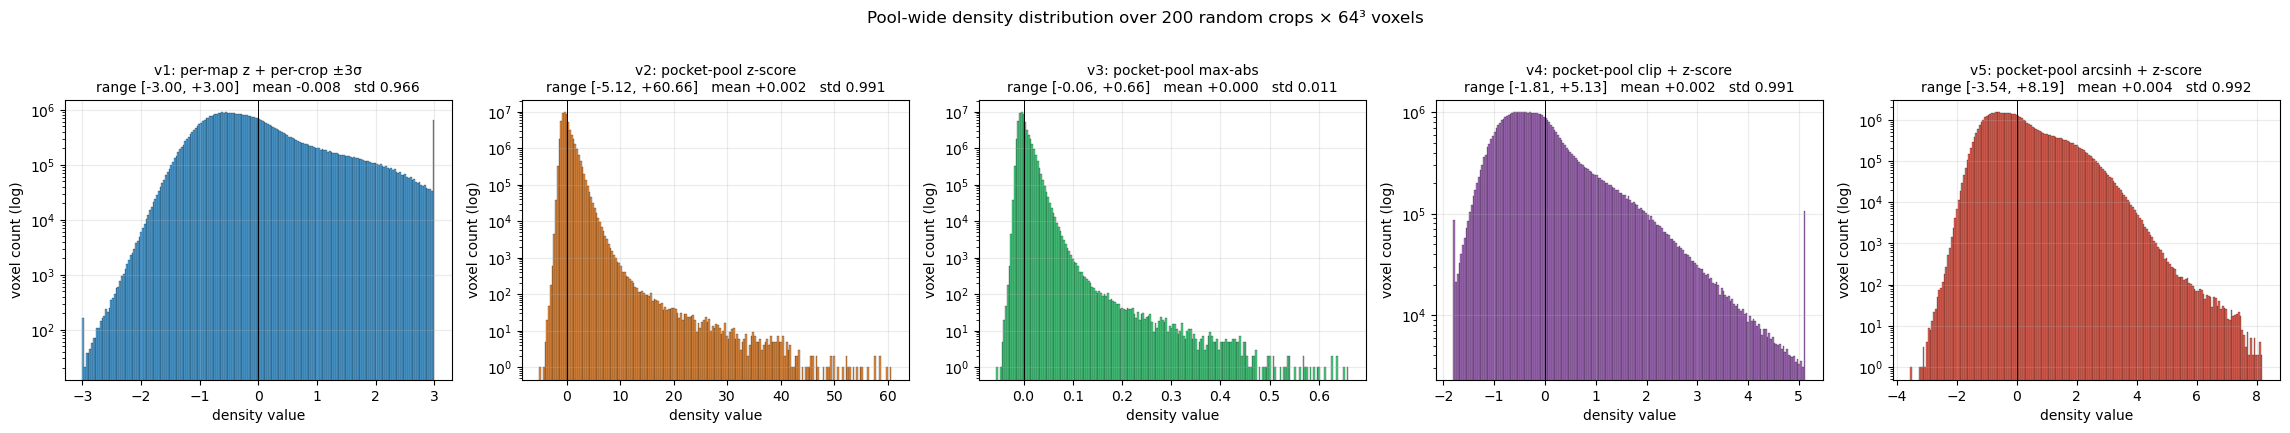

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(23, 4.2))
for ax, v in zip(axes, VERSIONS):
    vals = pooled[v]
    ax.hist(vals, bins=200, color=COLOR[v], edgecolor="black", linewidth=0.2, alpha=0.85)
    ax.set_yscale("log")
    ax.axvline(0, color="k", linewidth=0.7)
    ax.set_title(
        f"{LABEL[v]}\nrange [{vals.min():+.2f}, {vals.max():+.2f}]   "
        f"mean {vals.mean():+.3f}   std {vals.std():.3f}",
        fontsize=10,
    )
    ax.set_xlabel("density value")
    ax.set_ylabel("voxel count (log)")
    ax.grid(alpha=0.25)
fig.suptitle(f"Pool-wide density distribution over {N_SAMPLE} random crops × 64³ voxels", y=1.02)
fig.tight_layout()
plt.show()

## 2. Per-crop statistic distributions

For each crop in the sample, compute its own mean / std / min / max. Plot the distribution of those per-crop stats across versions.

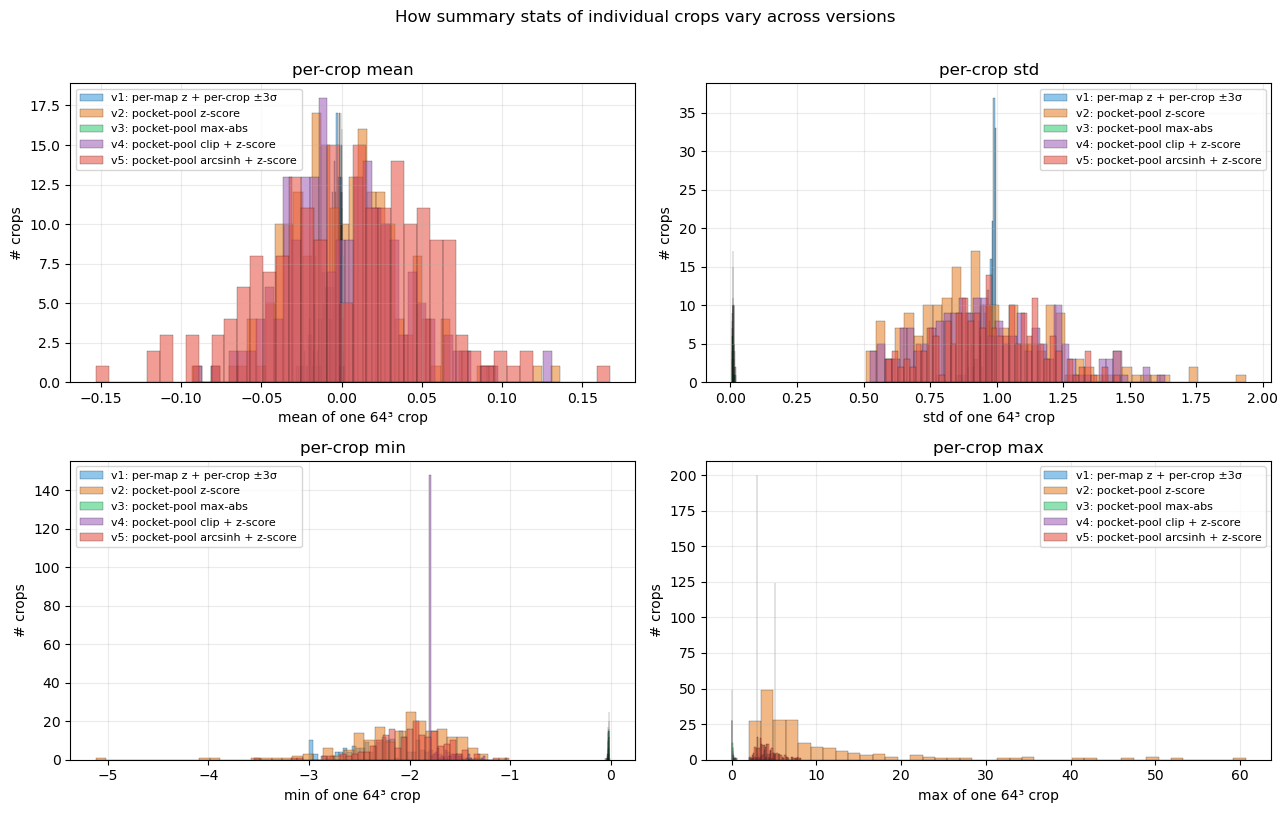

In [4]:
per_crop_stats = {v: {"mean": [], "std": [], "min": [], "max": []} for v in VERSIONS}
for v in VERSIONS:
    for pid in sample_pids:
        a = load_density(v, pid)
        per_crop_stats[v]["mean"].append(a.mean())
        per_crop_stats[v]["std"].append(a.std())
        per_crop_stats[v]["min"].append(a.min())
        per_crop_stats[v]["max"].append(a.max())

for v in VERSIONS:
    for k in per_crop_stats[v]:
        per_crop_stats[v][k] = np.array(per_crop_stats[v][k])

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, key in zip(axes.flat, ["mean", "std", "min", "max"]):
    for v in VERSIONS:
        ax.hist(per_crop_stats[v][key], bins=40, alpha=0.55,
                color=COLOR[v], label=LABEL[v], edgecolor="black", linewidth=0.3)
    ax.set_title(f"per-crop {key}")
    ax.set_xlabel(f"{key} of one 64³ crop")
    ax.set_ylabel("# crops")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
fig.suptitle("How summary stats of individual crops vary across versions", y=1.01)
fig.tight_layout()
plt.show()

## 3. Same-PDB-ID side-by-side

Pick one complex (`PID` below); show the central slice along each of the three axes for v1, v2, v3 — so the same physical pocket is visualised under all three normalisations. The middle-row strip plots the value histogram per version for this single crop.

In [5]:
PID = "10gs"          # change to inspect a different complex (must exist in all versions)

crops = {v: load_density(v, PID) for v in VERSIONS}
for v, a in crops.items():
    print(f"  {v}  shape={a.shape}  range [{a.min():+.3f}, {a.max():+.3f}]  "
          f"mean {a.mean():+.4f}  std {a.std():.4f}")

  v1  shape=(64, 64, 64)  range [-2.535, +3.000]  mean -0.0061  std 0.9788
  v2  shape=(64, 64, 64)  range [-2.037, +4.551]  mean -0.0519  std 0.7832
  v3  shape=(64, 64, 64)  range [-0.022, +0.050]  mean -0.0005  std 0.0085
  v4  shape=(64, 64, 64)  range [-1.806, +4.684]  mean -0.0503  std 0.8048
  v5  shape=(64, 64, 64)  range [-2.008, +3.424]  mean -0.0355  std 0.8528


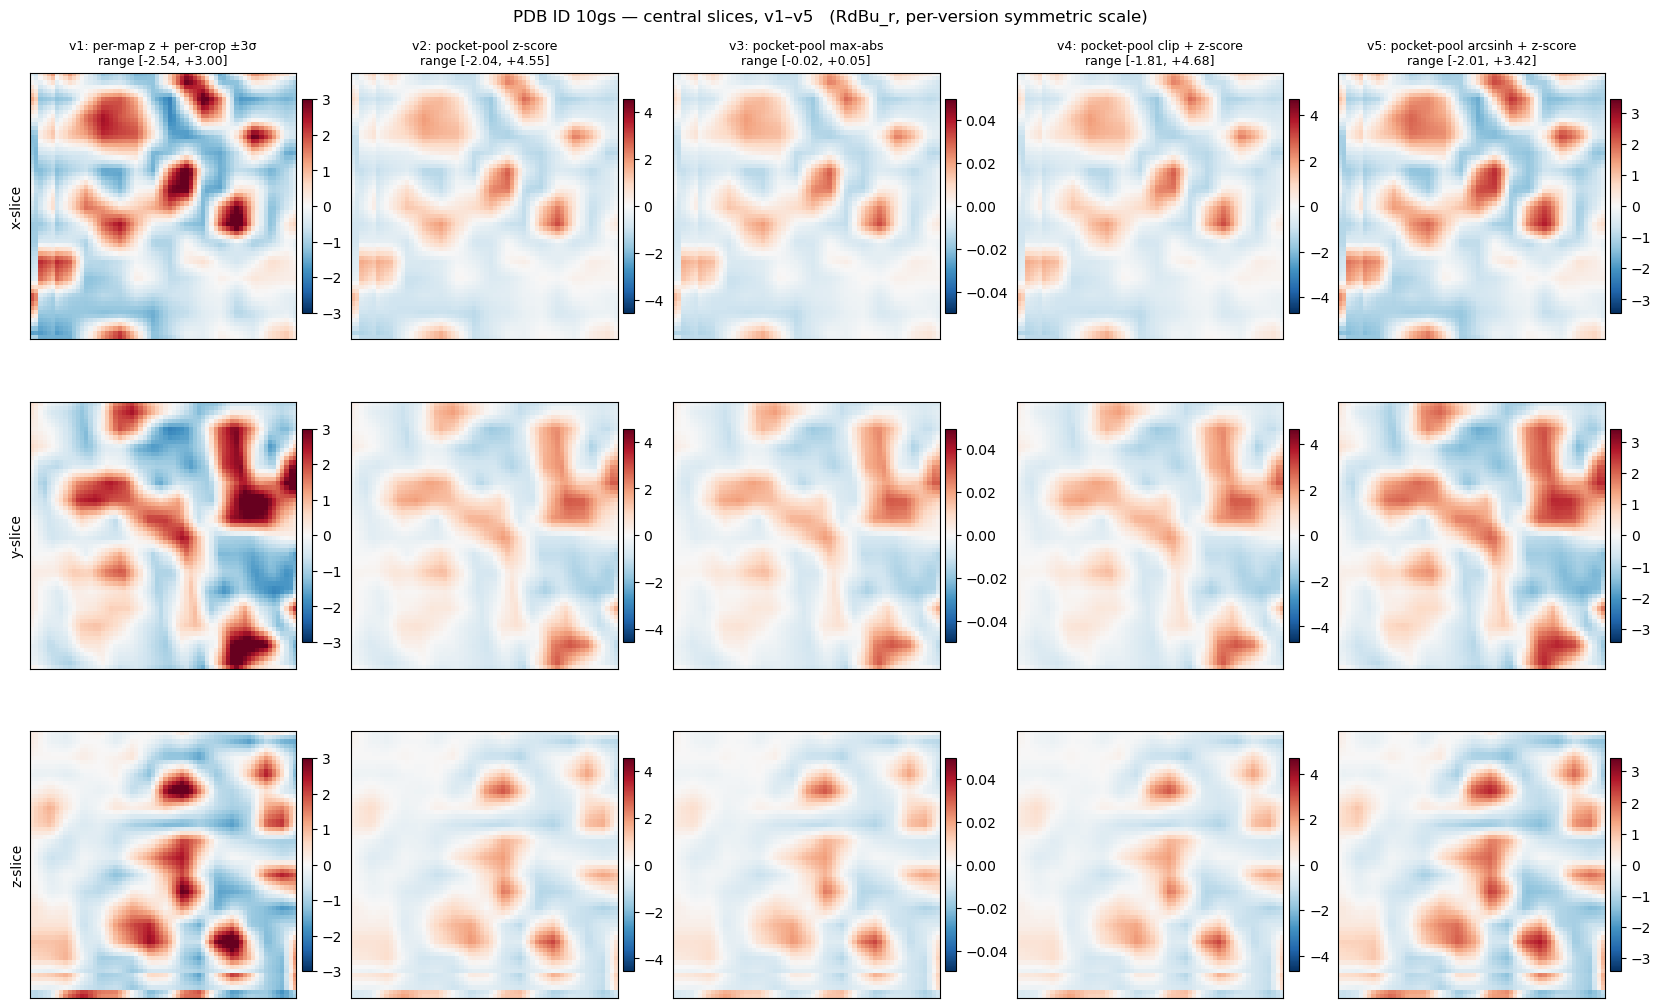

In [6]:
def take_slice(vol, axis, offset=0):
    G = vol.shape[-1]
    idx = G // 2 + offset
    return vol[idx, :, :] if axis == 'x' else vol[:, idx, :] if axis == 'y' else vol[:, :, idx]

fig, axes = plt.subplots(3, 5, figsize=(16.5, 10), constrained_layout=True)
for col, v in enumerate(VERSIONS):
    a = crops[v]
    vmax = max(abs(a.min()), abs(a.max()))
    for row, axis in enumerate(['x', 'y', 'z']):
        ax = axes[row, col]
        im = ax.imshow(take_slice(a, axis).T, origin='lower',
                       cmap='RdBu_r', vmin=-vmax, vmax=+vmax)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(f"{LABEL[v]}\nrange [{a.min():+.2f}, {a.max():+.2f}]",
                         fontsize=9)
        if col == 0:
            ax.set_ylabel(f"{axis}-slice", fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
fig.suptitle(f"PDB ID {PID} — central slices, v1–v5   "
             f"(RdBu_r, per-version symmetric scale)", y=1.02)
plt.show()

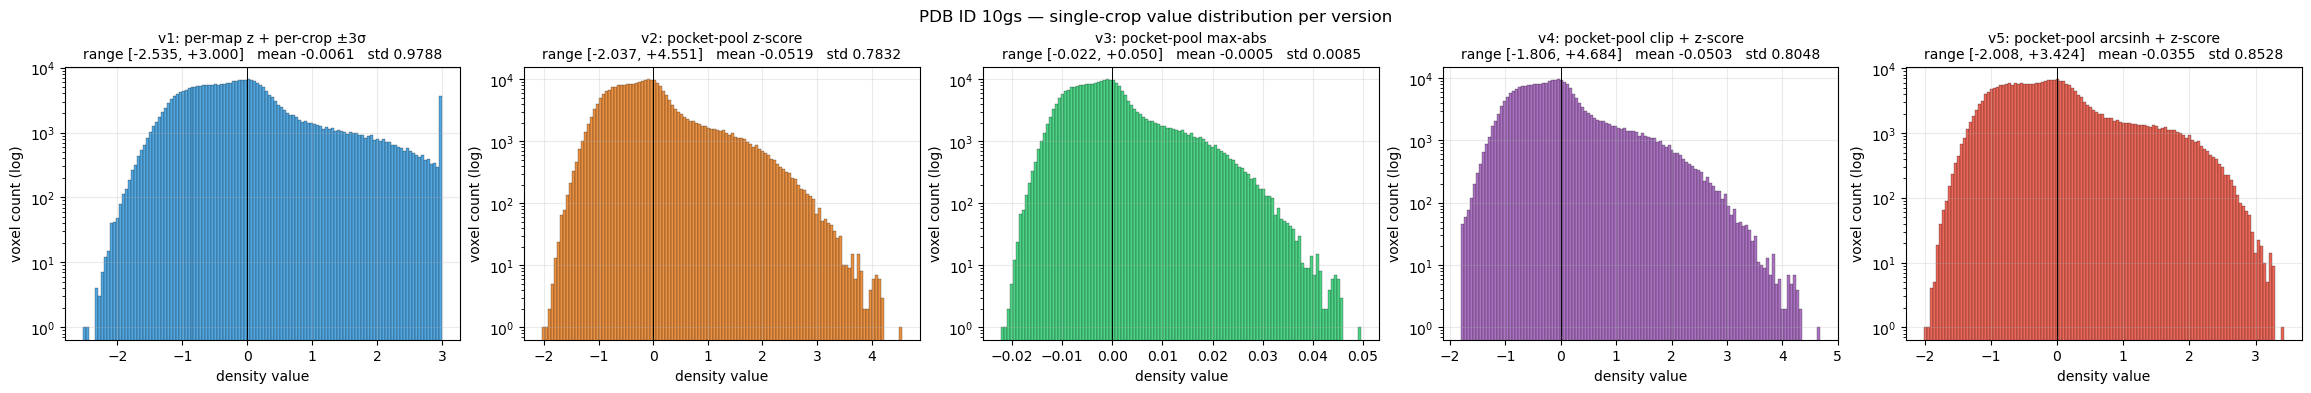

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(23, 3.6), constrained_layout=True)
for ax, v in zip(axes, VERSIONS):
    vals = crops[v].ravel()
    ax.hist(vals, bins=120, color=COLOR[v], edgecolor="black", linewidth=0.2, alpha=0.85)
    ax.set_yscale("log")
    ax.axvline(0, color="k", linewidth=0.7)
    ax.set_title(
        f"{LABEL[v]}\n"
        f"range [{vals.min():+.3f}, {vals.max():+.3f}]   "
        f"mean {vals.mean():+.4f}   std {vals.std():.4f}",
        fontsize=10,
    )
    ax.set_xlabel("density value")
    ax.set_ylabel("voxel count (log)")
    ax.grid(alpha=0.25)
fig.suptitle(f"PDB ID {PID} — single-crop value distribution per version", y=1.05)
plt.show()

## 4. Pool stats from `stats.json`

The exact pool scalars used to construct v2–v5 are recorded in each version's `stats.json`.

In [8]:
for v in ["v2", "v3", "v4", "v5"]:
    sj = VOX_DIRS[v] / "stats.json"
    if sj.exists():
        print(f"── {v} stats.json")
        print(json.dumps(json.loads(sj.read_text()), indent=2))
        print()

── v2 stats.json
{
  "scheme": "pocket-pool z-score",
  "formula": "x' = (x - mu) / sigma",
  "mu": 0.0021616171884043488,
  "sigma": 0.32965135634508996,
  "n_crops": 4827,
  "n_voxels_total": 1265369088,
  "raw_min": -2.3028321266174316,
  "raw_max": 30.303401947021484
}

── v3 stats.json
{
  "scheme": "pocket-pool symmetric max-abs",
  "formula": "x' = x / max_abs",
  "max_abs": 30.303401947021484,
  "n_crops": 4827,
  "n_voxels_total": 1265369088,
  "raw_min": -2.3028321266174316,
  "raw_max": 30.303401947021484
}

── v4 stats.json
{
  "scheme": "pocket-pool clip + z-score",
  "formula": "x' = (clip(x, [clip_lo, clip_hi]) - mu_clip) / sigma_clip",
  "clip_lo_raw": -0.578,
  "clip_hi_raw": 1.647,
  "mu_clip": 0.0011908855786452411,
  "sigma_clip": 0.3207678646958179,
  "n_crops": 4827,
  "n_voxels_total": 1265369088,
  "raw_min": -2.3028321266174316,
  "raw_max": 30.303401947021484
}

── v5 stats.json
{
  "scheme": "pocket-pool arcsinh soft-squash + z-score (no clip)",
  "formula": 

## 5. Gradient-magnitude ‖∇ρ‖ distribution

The density-MAE can add a **gradient-magnitude edge channel** ‖∇ρ‖ next to the raw density (the `with_gradmag` runs, e.g. `260603_…_gradmag`). It is built from the *normalised* density crop with central finite differences (`gradient_magnitude3d`) and then **per-sample z-scored** (`per_sample_zscore`) — so whichever density normalisation (v1–v5) we pick propagates into the edge channel the model actually consumes.

Below ‖∇ρ‖ is compared across the five variants, both **raw** (the scale story) and **z-scored** (the model input), reusing the same `sample_pids` / `PID` as the density views above. Watch for the linear-vs-nonlinear split: v2 and v3 are *linear* rescalings of the same raw density, so their z-scored edges coincide, while the *nonlinearity* in v1/v4 (clip) and v5 (arcsinh) reshapes them.

In [9]:
# ── ‖∇ρ‖ exactly as the VoxBind gradmag channel: central-difference gradient
#    magnitude, then per-sample z-score (what the model sees). Same ops as dataset/train. ──
import torch
from voxbind.models.density_mae import gradient_magnitude3d, per_sample_zscore

def gradmag(arr):
    """(raw ‖∇ρ‖, z-scored ‖∇ρ‖) for a 64³ density crop, via the pipeline ops."""
    t = torch.from_numpy(np.ascontiguousarray(arr, np.float32))[None, None]   # (1,1,G,G,G)
    g = gradient_magnitude3d(t)
    return g[0, 0].numpy(), per_sample_zscore(g)[0, 0].numpy()

# Pool ‖∇ρ‖ over the same sample_pids as §1 (identical crops → fair version comparison).
gm_raw_pool, gm_z_pool = {v: [] for v in VERSIONS}, {v: [] for v in VERSIONS}
for v in VERSIONS:
    for pid in sample_pids:
        r, z = gradmag(load_density(v, pid))
        gm_raw_pool[v].append(r.ravel()); gm_z_pool[v].append(z.ravel())
    gm_raw_pool[v] = np.concatenate(gm_raw_pool[v])
    gm_z_pool[v]   = np.concatenate(gm_z_pool[v])
    r = gm_raw_pool[v]
    print(f"  {v:3s} ‖∇ρ‖ raw: range [{r.min():.4f}, {r.max():8.4f}]   mean {r.mean():.4f}   std {r.std():.4f}")

# Linear vs nonlinear normalisation: v2/v3 are pure rescalings of the raw density, so their
# per-sample z-scored ‖∇ρ‖ should coincide; the clip-based v1/v4 are nonlinear and should differ.
print(f"\n  max|z‖∇ρ‖  v2 − v3| = {np.abs(gm_z_pool['v2'] - gm_z_pool['v3']).max():.4f}   "
      f"(≈0 → linear rescale, identical edge channel)")
print(f"  max|z‖∇ρ‖  v1 − v4| = {np.abs(gm_z_pool['v1'] - gm_z_pool['v4']).max():.4f}   "
      f"(>0 → clipping reshapes the edges)")

  v1  ‖∇ρ‖ raw: range [0.0000,   3.6803]   mean 0.3449   std 0.2511


  v2  ‖∇ρ‖ raw: range [0.0002,  26.5420]   mean 0.3427   std 0.3227


  v3  ‖∇ρ‖ raw: range [0.0000,   0.2888]   mean 0.0037   std 0.0035


  v4  ‖∇ρ‖ raw: range [0.0000,   5.9221]   mean 0.3477   std 0.3041


  v5  ‖∇ρ‖ raw: range [0.0002,   5.4458]   mean 0.3551   std 0.2740



  max|z‖∇ρ‖  v2 − v3| = 0.0337   (≈0 → linear rescale, identical edge channel)


  max|z‖∇ρ‖  v1 − v4| = 11.7570   (>0 → clipping reshapes the edges)


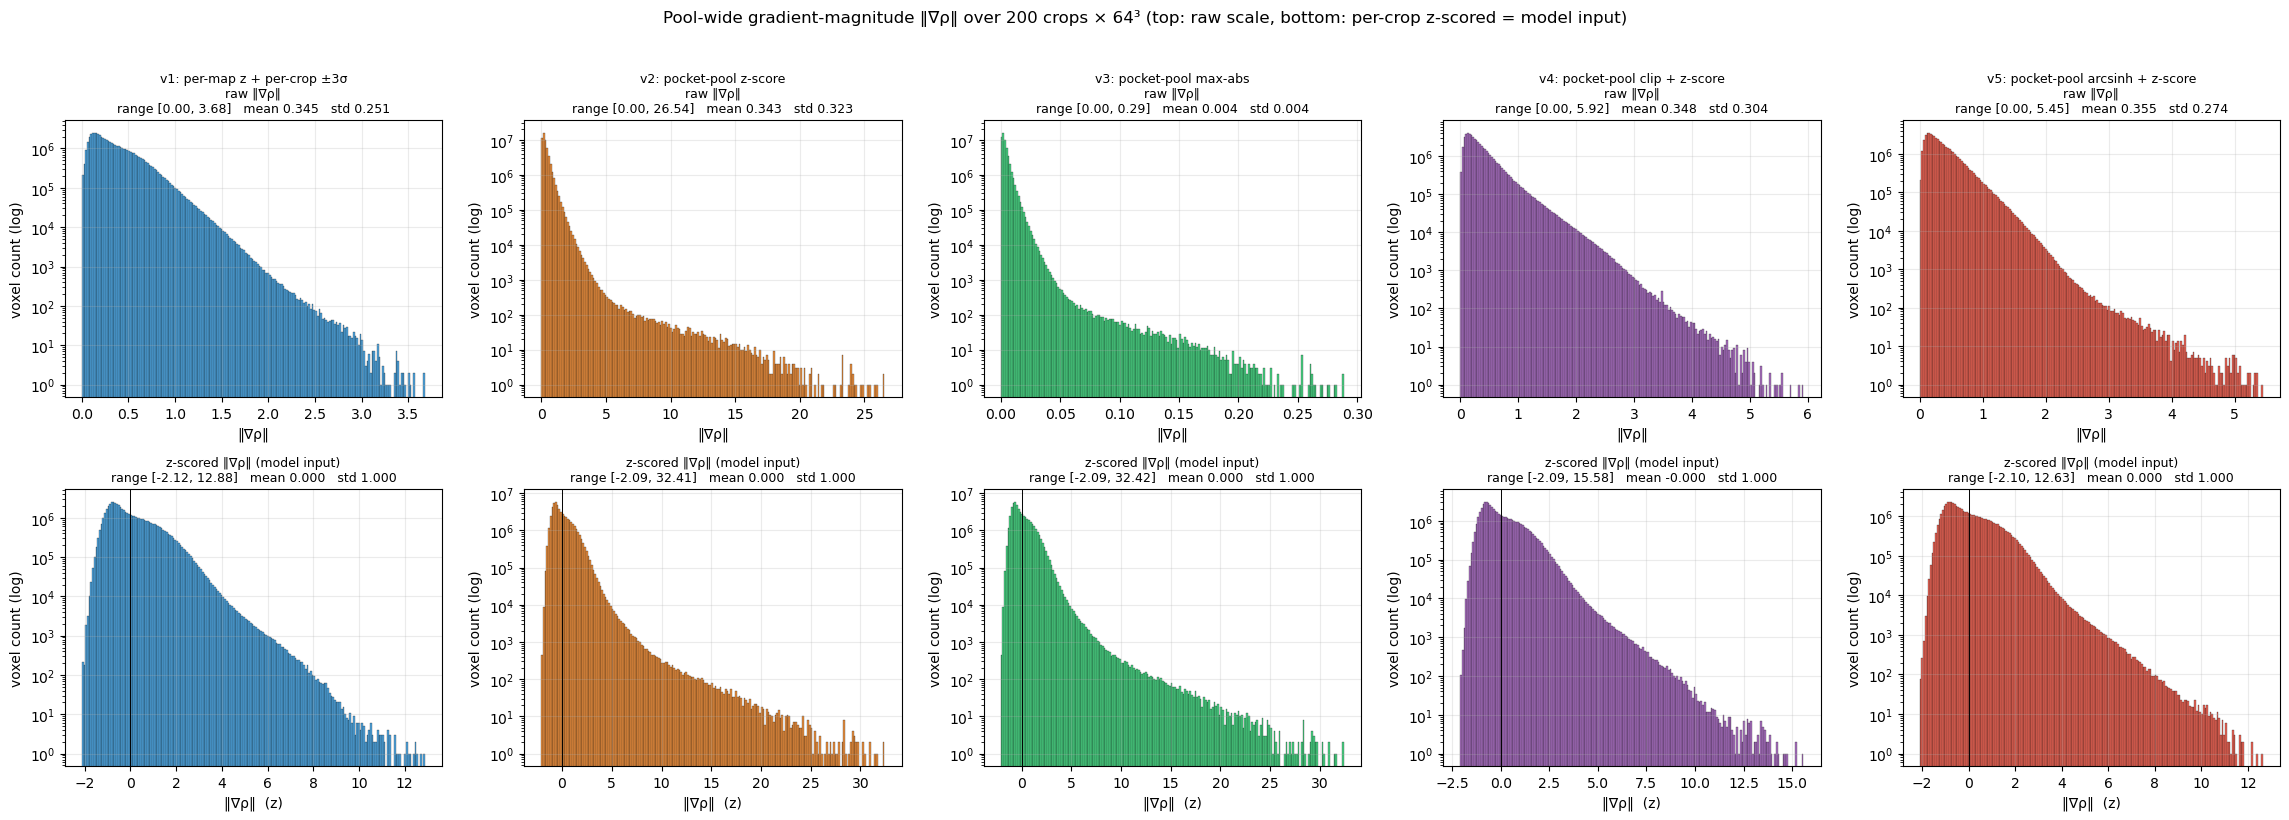

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(23, 8))
for col, v in enumerate(VERSIONS):
    for row, (pool, tag) in enumerate([(gm_raw_pool, "raw ‖∇ρ‖"),
                                       (gm_z_pool, "z-scored ‖∇ρ‖ (model input)")]):
        ax = axes[row, col]
        vals = pool[v]
        ax.hist(vals, bins=200, color=COLOR[v], edgecolor="black", linewidth=0.2, alpha=0.85)
        ax.set_yscale("log"); ax.grid(alpha=0.25)
        if row == 1:
            ax.axvline(0, color="k", linewidth=0.7)
        head = (LABEL[v] + "\n") if row == 0 else ""
        ax.set_title(f"{head}{tag}\nrange [{vals.min():.2f}, {vals.max():.2f}]   "
                     f"mean {vals.mean():.3f}   std {vals.std():.3f}", fontsize=9)
        ax.set_xlabel("‖∇ρ‖" + ("  (z)" if row == 1 else ""))
        ax.set_ylabel("voxel count (log)")
fig.suptitle(f"Pool-wide gradient-magnitude ‖∇ρ‖ over {N_SAMPLE} crops × 64³ "
             f"(top: raw scale, bottom: per-crop z-scored = model input)", y=1.02)
fig.tight_layout()
plt.show()

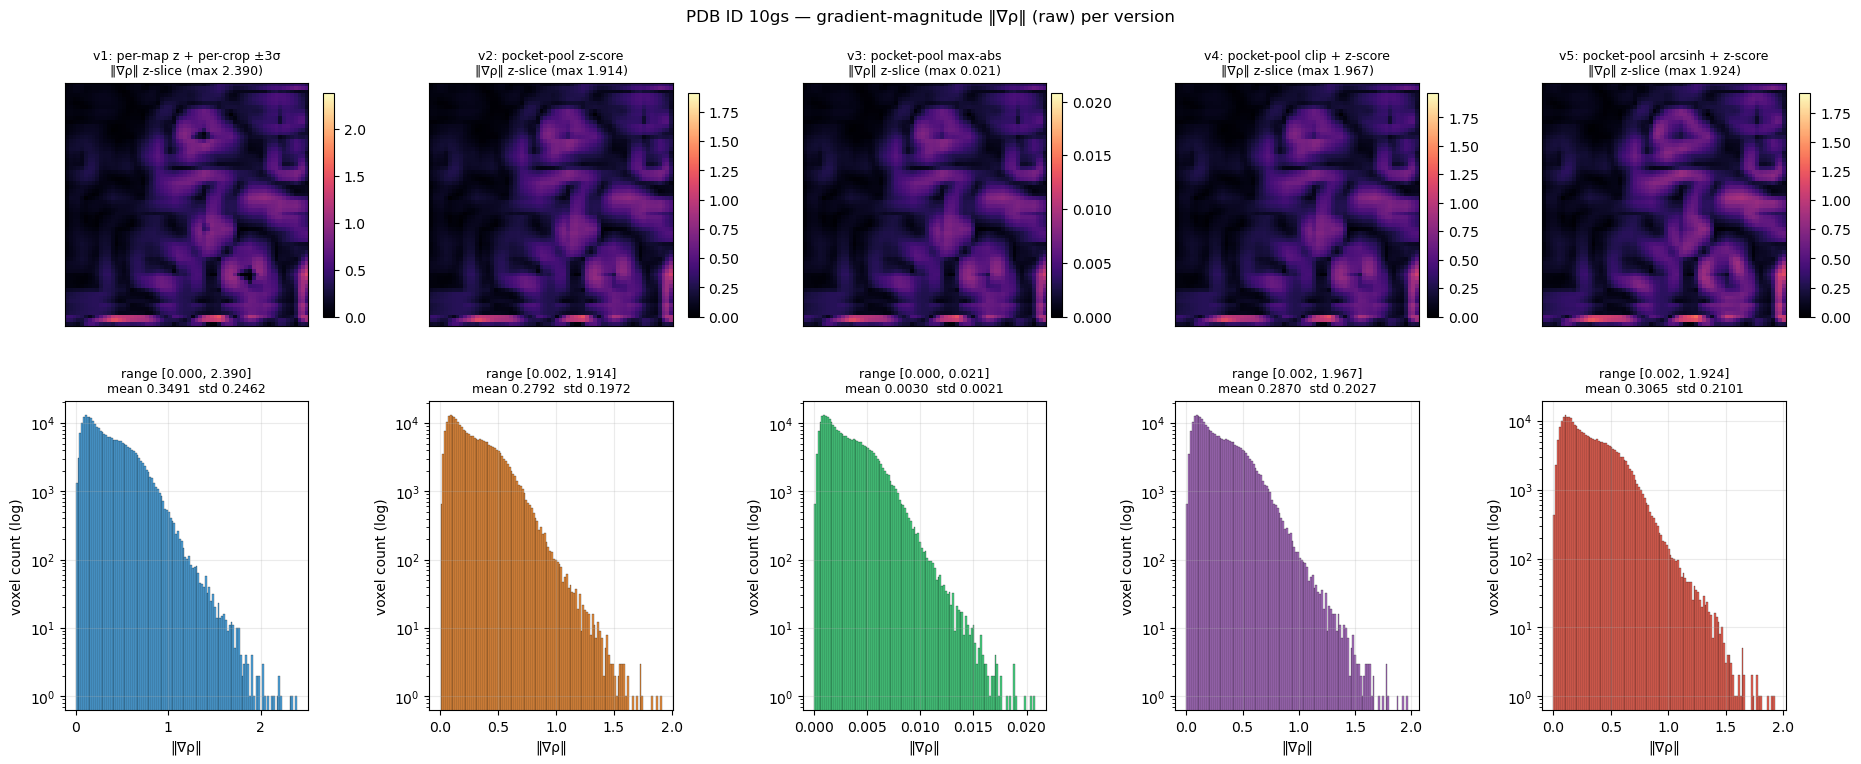

In [11]:
# Same physical pocket (PID from §3) as a ‖∇ρ‖ edge map + its value distribution per version.
gm_pid = {v: gradmag(crops[v])[0] for v in VERSIONS}      # raw ‖∇ρ‖ (z-score only rescales it)

fig, axes = plt.subplots(2, 5, figsize=(18.5, 7.2), constrained_layout=True)
for col, v in enumerate(VERSIONS):
    g = gm_pid[v]
    im = axes[0, col].imshow(take_slice(g, 'z').T, origin='lower', cmap='magma', vmin=0, vmax=g.max())
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])
    axes[0, col].set_title(f"{LABEL[v]}\n‖∇ρ‖ z-slice (max {g.max():.3f})", fontsize=9)
    plt.colorbar(im, ax=axes[0, col], fraction=0.046, pad=0.02)
    vals = g.ravel()
    axes[1, col].hist(vals, bins=120, color=COLOR[v], edgecolor="black", linewidth=0.2, alpha=0.85)
    axes[1, col].set_yscale("log"); axes[1, col].grid(alpha=0.25)
    axes[1, col].set_title(f"range [{vals.min():.3f}, {vals.max():.3f}]\n"
                           f"mean {vals.mean():.4f}  std {vals.std():.4f}", fontsize=9)
    axes[1, col].set_xlabel("‖∇ρ‖"); axes[1, col].set_ylabel("voxel count (log)")
fig.suptitle(f"PDB ID {PID} — gradient-magnitude ‖∇ρ‖ (raw) per version", y=1.04)
plt.show()

## Reading

Things to notice:

- **v1's histogram is hard-truncated at ±3** — the bins outside that range are empty (per-crop ±3σ clip + re-z-score). Heavy-atom peaks that were +8σ raw are pinned to +3 with no information about how much further they extended.
- **v2's histogram retains the long positive tail** — values out to +90 or so for the strongest metal peaks. Solvent / typical atom values cluster near 0 within a few σ_pool.
- **v3's histogram is in [−1, +1] strict** but most of the mass is squeezed into a tiny band near 0 because the single brightest peak (around +30 raw) sets the scale.
- **v4's histogram looks like v2's core but bounded** — the long positive tail of v2 is folded onto the clip ceiling (`+1.647` raw → ≈ +5.2 after z-score), so the bright peaks survive as a spike at the top edge instead of running out to +60. Unlike v1's hard ±3, v4's clip is a fixed *physical* density threshold (raw 2Fo-Fc units) rather than a per-crop ±3σ; and unlike v3, typical-atom signal keeps unit-ish scale instead of collapsing to ~0.01. Only ~0.1–0.15 % of voxels actually hit the clip, so almost all real density passes through untouched.
- **v5 soft-squashes instead of clipping** — `arcsinh(x / 0.5)` then z-score. arcsinh is ~linear near 0 (bulk preserved) and ~log for large values, so the +30 metal peak compresses *smoothly* to ≈ +9 (vs +92 for a plain z-score) with **no hard cutoff and no pile-up spike** — every voxel is kept, unlike v4/v1 which pin the tail to a clip ceiling. The histogram therefore tapers off continuously on the right instead of ending in an edge spike. Still unit-scale ("loud") like v2/v4. It's the "use all the data, tame the tail without clamping" option.
- The **per-crop std** plot (§2) reveals the trade-off directly: v1's per-crop std is ≈ 1 by construction; v2/v3/v4/v5's per-crop std varies *across* crops (some crops are denser than others — that signal survives in v2/v3/v4/v5 and is lost in v1).
- The **same-PID slices** (§3) show the same physical pocket under each transform — relative spatial pattern is preserved across all five; only the value scale differs.
- **The gradient-magnitude edge channel ‖∇ρ‖ (§5) inherits the normalisation's scale.** *Raw* ‖∇ρ‖ tracks the density scale directly: v2's long tail gives the widest gradients (a heavy positive tail from the sharp metal-peak edges), v3 collapses them ~100× (mean ‖∇ρ‖ ≈ 0.003 vs ≈ 0.30 for the others — the same squashing that hits v3's density), and v1/v4's clip plus v5's arcsinh all keep gradients bounded.
- **After per-sample z-score (the model input), v2 and v3 become identical edge channels** (max abs per-voxel difference ≈ 0.03 ≈ numerical noise): both are *linear* rescalings of the raw density, and z-scoring cancels the global scale — so a pure rescale leaves the ‖∇ρ‖ channel unchanged. The **nonlinear variants differ** (v1/v4 clip, v5 arcsinh): clipping flattens the brightest peaks into plateaus whose gradient is zero, and arcsinh compresses them — both reshape the edge distribution. Net for the gradmag channel: only the normalisation's *nonlinearity* matters — v4 (clip) and v5 (arcsinh) give a bounded, non-degenerate ‖∇ρ‖, whereas v3's raw edges are the most degenerate before z-score.